In [ ]:
!pip install np_utils

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for np_utils: filename=np_utils-0.6.0-py3-none-any.whl size=56437 sha256=357d07c570e528a0356e9bf4b173566fa51603c8854b959f2baf650a72606629
  Stored in directory: /root/.cache/pip/wheels/b6/c7/50/2307607f44366dd021209f660045f8d51cb976514d30be7cc7
Successfully built np_utils


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7,7) # Make the figures a bit bigger

from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation
from keras import utils
#from keras.utils import np_utils

In [ ]:
nb_classes = 10

# the data, shuffled and split between tran and test sets
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print("X_train original shape", X_train.shape)
print("y_train original shape", y_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
X_train original shape (60000, 28, 28)
y_train original shape (60000,)


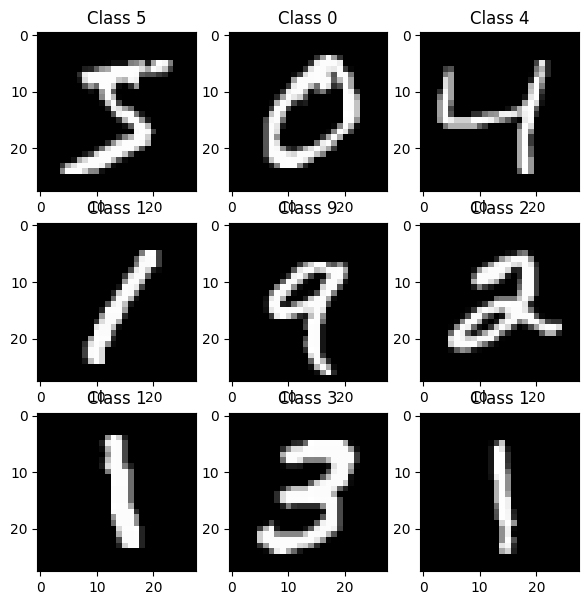

In [ ]:
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray', interpolation='none')
    plt.title("Class {}".format(y_train[i]))

0


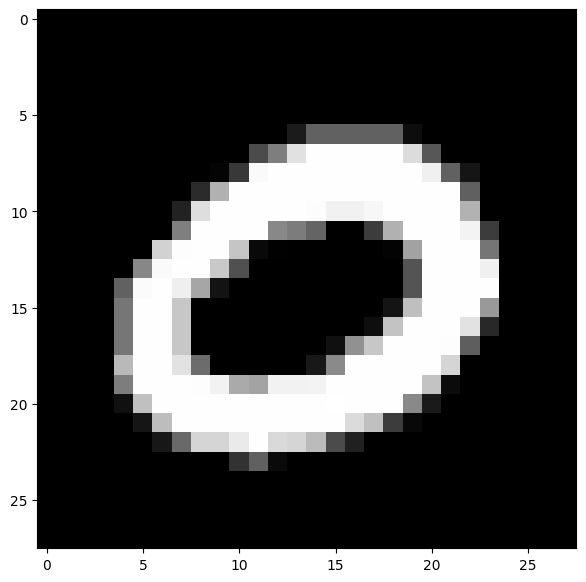

In [ ]:
i = 6001
print(y_train[i])
plt.imshow(X_train[i], cmap='gray', interpolation='none')

# Nejjednodušší Neuronová síť, proto 2D -> 1D (není příliš moudré to takto udělat)
Také trochu normalizace

In [ ]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255
print("Training matrix shape", X_train.shape)
print("Testing matrix shape", X_test.shape)

Training matrix shape (60000, 784)
Testing matrix shape (10000, 784)


# Na výstupu potřebujeme kategorie
0 -> [1, 0, 0, 0, 0, 0, 0, 0, 0]

1 -> [0, 1, 0, 0, 0, 0, 0, 0, 0]

2 -> [0, 0, 1, 0, 0, 0, 0, 0, 0]

atd.

In [ ]:
Y_train = utils.to_categorical(y_train, nb_classes)
Y_test = utils.to_categorical(y_test, nb_classes)

Y_test.shape

(10000, 10)

# Návrh Neuronové sítě

In [ ]:
model = Sequential()
model.add(Dense(512, input_shape=(784,)))
#model.add(Activation('relu'))
#model.add(Dropout(0.2))
#model.add(Dense(512))
#model.add(Activation('relu'))
model.add(Dropout(0.8))
model.add(Dense(50))
#model.add(Dropout(0.2))
model.add(Dense(10))
model.add(Activation('softmax'))

# Jak se bude model optimalizovat během učení?

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
model.fit(X_train, Y_train,
          batch_size=5024, epochs=4,
          verbose=1,
          validation_data=(X_test, Y_test))

Epoch 1/4
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 291ms/step - accuracy: 0.3750 - loss: 1.9915 - val_accuracy: 0.8599 - val_loss: 0.4755
Epoch 2/4
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.8134 - loss: 0.5907 - val_accuracy: 0.8921 - val_loss: 0.3711
Epoch 3/4
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 190ms/step - accuracy: 0.8550 - loss: 0.4792 - val_accuracy: 0.9043 - val_loss: 0.3371
Epoch 4/4
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - accuracy: 0.8742 - loss: 0.4271 - val_accuracy: 0.9112 - val_loss: 0.3156


# Podívejme se na výsledky

In [ ]:
score = model.evaluate(X_test, Y_test, verbose=0)
print('Test score:', score)

Test score: [0.2899754047393799, 0.9212999939918518]


In [ ]:
# The predict_classes function outputs the highest probability class
# according to the trained classifier for each input example.

#predicted_classes = model.predict_classes(X_test) # older version
predict_x=model.predict(X_test)
predicted_classes=np.argmax(predict_x,axis=1)

# Check which items we got right / wrong
correct_indices = np.nonzero(predicted_classes == y_test)[0]
incorrect_indices = np.nonzero(predicted_classes != y_test)[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


4
4


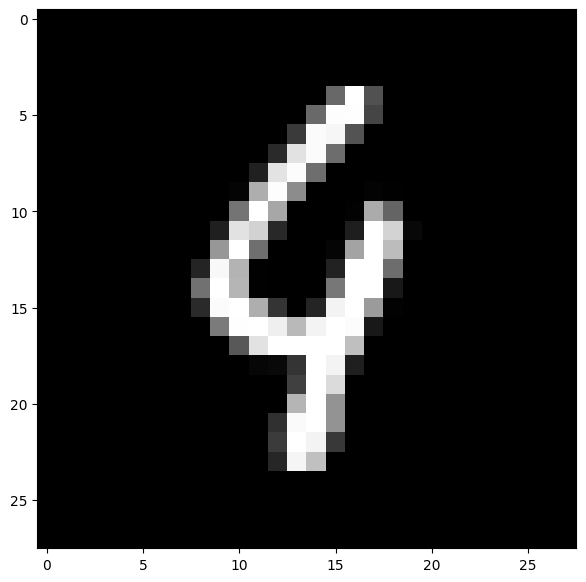

In [ ]:
print(predicted_classes[115])
print(y_test[115])
#print(incorrect_indices)
plt.imshow(X_test[115].reshape(28,28), cmap='gray', interpolation='none')

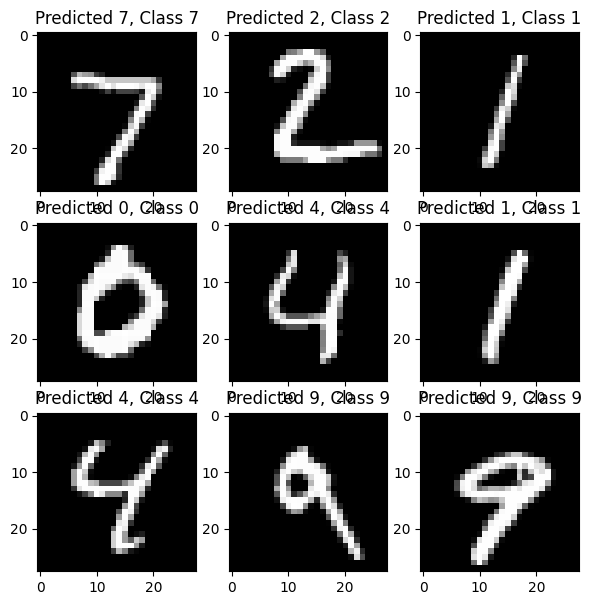

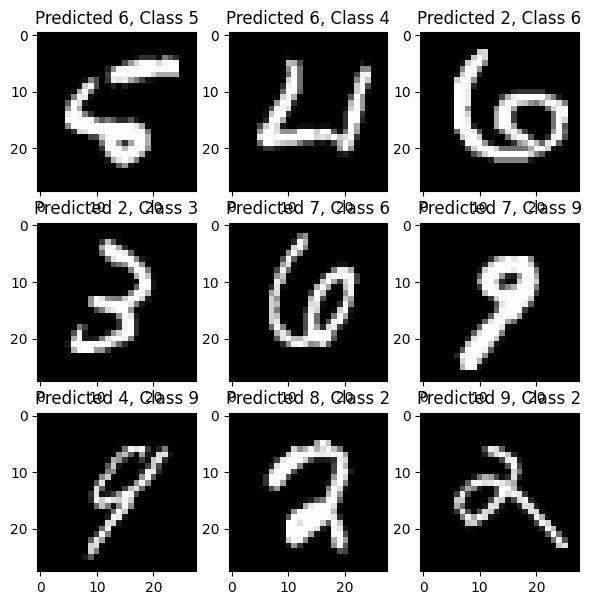

In [ ]:
plt.figure()
for i, correct in enumerate(correct_indices[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[correct].reshape(28,28), cmap='gray', interpolation='none')
    plt.title("Predicted {}, Class {}".format(predicted_classes[correct], y_test[correct]))

plt.figure()
for i, incorrect in enumerate(incorrect_indices[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[incorrect].reshape(28,28), cmap='gray', interpolation='none')
    plt.title("Predicted {}, Class {}".format(predicted_classes[incorrect], y_test[incorrect]))